<h1>Análise de dados LH Nautical LTDA</h1>
Neste notebook iremos fazer a análise exploratória dos dados da empresa LH Nautical para o desafio Dados I.A 


<h2>Bibliotecas necessárias</h2>

- Numpy
- Pandas
- Json
- Numpy
- Requests
- Matplotlib
- Sklearn / Scikit-learn

In [ ]:
#Instalação das bibliotecas
!pip install pandas plotly numpy statsmodels scikit-learn matplotlib

<h2>Importações</h2>

In [91]:
import pandas as pd
import json
import numpy as np
import requests
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error
from sklearn.metrics.pairwise import cosine_similarity
import plotly.express as px
import plotly.graph_objects as go

<h2>Configuração de caminhos (PATHS)</h2>

In [33]:
# Define a raiz do projeto (como o notebook está na pasta 'notebook', voltamos um nível)
BASE_DIR = Path('..')

# Mapeia os diretórios principais
DATA_DIR = BASE_DIR / 'datasets'
RAW_DIR = DATA_DIR / 'raw'
PROCESSED_DIR = DATA_DIR / 'processed'
OUTPUT_DIR = PROCESSED_DIR / 'output'

# --------------------------Define os arquivos------------------------------------------

# Questão 1
FILE_VENDAS = RAW_DIR / 'vendas_2023_2024.csv'

# Questão 2
FILE_PRODUTOS = RAW_DIR / 'produtos_raw.csv'
FILE_PRODUTOS_PROCESSED = PROCESSED_DIR / 'produtos_processed.csv'
FILE_PREJUIZO = OUTPUT_DIR / 'relacao_prejuizo'

# Questão 3
FILE_CUSTOS_JSON = RAW_DIR / 'custos_importacao.json'
FILE_CUSTOS_NORM = PROCESSED_DIR / 'custos_importacao_normalizado.csv'

# Questão 4
FILE_COTACAO = PROCESSED_DIR / 'cotacao_dolar.csv'
FILE_CSV_SAIDA = PROCESSED_DIR / 'custos_importacao_normalizado.csv'
FILE_JSON = RAW_DIR / 'custos_importacao.json'
FILE_RELACAO_PREJUIZO = OUTPUT_DIR / 'relacao_prejuizo.csv'

# Questão 8
FILE_VENDAS_NORMALIZADA = PROCESSED_DIR / 'vendas_normalizadas.csv'

---
<h1>Questão 1</h1>

<h4>Importamos o arquivo csv e atribuimos ele a variável vendas</h4>

In [34]:
vendas = pd.read_csv(FILE_VENDAS, skip_blank_lines=False)

In [35]:
vendas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9901 entries, 0 to 9900
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   id          9895 non-null   float64
 1   id_client   9895 non-null   float64
 2   id_product  9895 non-null   float64
 3   qtd         9895 non-null   float64
 4   total       9895 non-null   float64
 5   sale_date   9895 non-null   object 
dtypes: float64(5), object(1)
memory usage: 464.2+ KB


A tabela possui 6 colunas distintas (id, id_client, id_product, qtd, total e sale_date).\
Nossa tabela contém 9011 linhas no total, o que pode ser confirmado em "RangeIndex: 9901 entries"

In [36]:
# Calculando mínimo, máximo e média
resumo = vendas['total'].agg(['min', 'max', 'mean'])

print(resumo.round(2))

min         294.50
max     2222973.00
mean     263797.83
Name: total, dtype: float64


<h4> Localizando possíveis linhas com valores nulos </h4>

In [58]:
# Lemos o arquivo forçando o Python a NÃO pular linhas vazias
df_investigacao = pd.read_csv(FILE_VENDAS, skip_blank_lines=False)

# Checando o novo total de linhas
print(f"Total de linhas lidas (sem pular vazias): {len(df_investigacao)}")

# Encontrando onde estão as linhas "fantasmas" (totalmente vazias)
linhas_vazias = df_investigacao[df_investigacao.isnull().all(axis=1)]

print(f"Encontramos {len(linhas_vazias)} linhas totalmente em branco.")

# Exibe os índices (número da linha) para você conferir
display(linhas_vazias)

Total de linhas lidas (sem pular vazias): 9901
Encontramos 6 linhas totalmente em branco.


,id,id_client,id_product,qtd,total,sale_date
1537,NaN,NaN,NaN,NaN,NaN,NaN
2705,NaN,NaN,NaN,NaN,NaN,NaN
5012,NaN,NaN,NaN,NaN,NaN,NaN
5988,NaN,NaN,NaN,NaN,NaN,NaN
6046,NaN,NaN,NaN,NaN,NaN,NaN
6112,NaN,NaN,NaN,NaN,NaN,NaN


---
## Questão 2

In [59]:
produtos_2 = pd.read_csv(FILE_PRODUTOS, skip_blank_lines=False)

In [60]:
produtos_2.head()

,name,price,code,actual_category
0,Transponder AIS Maré Magnum,R$ 33122.52,1,ELETRONICOS
1,Transponder Furuno Marlin,R$ 13998.15,2,ELETRONICOS
2,Radar Furuno Pulse Leviathan,R$ 9024.19,3,E L E T R Ô N I C O S
3,Rádio AIS Hydro Tidal Zen,R$ 3381.88,4,Eletrunicos
4,Piloto Automático Furuno Storm,R$ 23669.01,5,Eletronicoz


In [61]:
# Isso vai listar todas as formas únicas que estão escritas na coluna e quantas vezes aparecem.
produtos_2['actual_category'].value_counts(dropna=False)

actual_category
AncorageM                9
Ancoraguem               8
Propução                 8
Eletronicoz              7
eletrônicos              7
ELETRONICOS              6
PROPULSAO                6
E L E T R Ô N I C O S    6
P R O P U L S Ã O        6
propulsão                6
Encoragem                5
Propulção                5
Prop                     5
Propulssão               5
aNcOrAgEm                5
A N C O R A G E M        5
Eletrunicos              5
Ancorajm                 5
eLeTrÔnIcOs              5
propulsao                4
Eletrônicos              4
EletrônicoS              3
Ancorajem                3
Ancoragem                3
Propulçao                3
eletronicos              3
AnCoRaGeM                2
Propulsam                2
pRoPuLsÃo                2
Eletroniscos             2
Eletronicos              2
ancoragem                2
Ancorajen                2
ELEtRÔNICOS              1
PrOpUlSãO                1
ANCORAGEM                1
Encoragi    

<h4>Percebemos que existe inconsistência na classificação dos produtos, então vamos padronizar as categorias em 3 tipos.

In [62]:
# Transformamos tudo em texto minúsculo e removemos todos os espaços em branco
produtos_2['actual_category'] = produtos_2['actual_category'].astype(str).str.lower().str.replace(' ', '', regex=False)

# Mapeamento Inteligente por Padrões (Regras de busca)
# Se a string contiver esse "pedaço" de palavra, ele classifica corretamente
condicoes = [
    produtos_2['actual_category'].str.contains('eletr', na=False), # Pega eletronicos, eletrunicos, eletronicoz...
    produtos_2['actual_category'].str.contains('prop', na=False),  # Pega propulsao, propução, prop...
    produtos_2['actual_category'].str.contains('ncor', na=False)   # Pega ancoragem, encoragem, ancorajm...
]

# Os nomes oficiais que queremos aplicar
categorias_oficiais = ['eletrônicos', 'propulsão', 'ancoragem']

# Aplica a regra usando np.select
# Se o texto não se encaixar em nenhuma regra, ele vira 'outros'
produtos_2['actual_category'] = np.select(condicoes, categorias_oficiais, default='outros')

# Prova real para garantir que funcionou perfeitamente
print(produtos_2['actual_category'].value_counts())

actual_category
propulsão      53
ancoragem      53
eletrônicos    51
Name: count, dtype: int64


<h4>Formatando a coluna "price".

In [63]:
# Limpeza mais enxuta (apenas tirando R$ e espaços, mantendo o ponto original)
produtos_2['price'] = (
    produtos_2['price']
    .astype(str)                           
    .str.replace('R$', '', regex=False)    # Remove a letra R$
    .str.replace(' ', '', regex=False)     # Remove espaços em branco
    # Removemos aquelas linhas que trocavam o ponto e a vírgula!
)

# Conversão para numérico 
produtos_2['price'] = pd.to_numeric(produtos_2['price'], errors='coerce')

# Mostrar os primeiros 5 preços para garantir que os centavos ficaram no lugar certo
print(produtos_2['price'].head())

0    33122.52
1    13998.15
2     9024.19
3     3381.88
4    23669.01
Name: price, dtype: float64


<h4>Removendo duplicatas</h4>
Primeiro iremos verificar quantos nomes únicos existem


In [64]:
produtos_2['name'].value_counts(dropna=False)

name
Motor Diesel Yanmar Velocity 37HP                4
Boia de Arqueamento Delta Nexus                  3
GPS Lowrance Evo Storm Drift                     2
Cabo de Nylon Delta Velocity Core Mako           2
Transponder AIS Maré Magnum                      1
                                                ..
Motor Diesel Tohatsu Evo Zenith 16HP             1
Motor Diesel Honda Zen Tidal Mako 26HP           1
Motor Elétrico Torqeedo Zen Titan Hydra 129HP    1
Motor de Popa Yamaha Evo Dash 155HP              1
Cabo de Nylon Danforth Magnum Vox                1
Name: count, Length: 150, dtype: int64

Vamos verificar lado a lado os produtos duplicados para termos certeza de que eles são de fato o mesmo produto

In [65]:
# para garantir que os preços e códigos não sejam diferentes (ex: uma versão mais cara que a outra)
tabela_duplicatas = produtos_2[produtos_2.duplicated(subset=['name'], keep=False)].sort_values('name')
print("Linhas que estão duplicadas:\n", tabela_duplicatas)

Linhas que estão duplicadas:
                                        name      price  code actual_category
124         Boia de Arqueamento Delta Nexus    4349.86   145       ancoragem
150         Boia de Arqueamento Delta Nexus    4349.86   145       ancoragem
151         Boia de Arqueamento Delta Nexus    4349.86   145       ancoragem
131  Cabo de Nylon Delta Velocity Core Mako    1549.35   127       ancoragem
132  Cabo de Nylon Delta Velocity Core Mako    1549.35   127       ancoragem
36             GPS Lowrance Evo Storm Drift    6067.71    37     eletrônicos
37             GPS Lowrance Evo Storm Drift    6067.71    37     eletrônicos
62        Motor Diesel Yanmar Velocity 37HP  102221.97    62       propulsão
63        Motor Diesel Yanmar Velocity 37HP  102221.97    62       propulsão
64        Motor Diesel Yanmar Velocity 37HP  102221.97    62       propulsão
65        Motor Diesel Yanmar Velocity 37HP  102221.97    62       propulsão


In [66]:
# keep='first' Mantém a primeira vez que o produto apareceu e apaga as repetições abaixo
produtos_2 = produtos_2.drop_duplicates(subset=['name'], keep='first')

# Prova real
print(f"Total de linhas após limpeza: {produtos_2.shape[0]}") # Deve retornar 150

Total de linhas após limpeza: 150


In [67]:
# Exporta o arquivo csv no diretorio de arquivos processados
produtos_2.to_csv(FILE_PRODUTOS_PROCESSED, index=False)

<h2>Construindo nosso gráfico

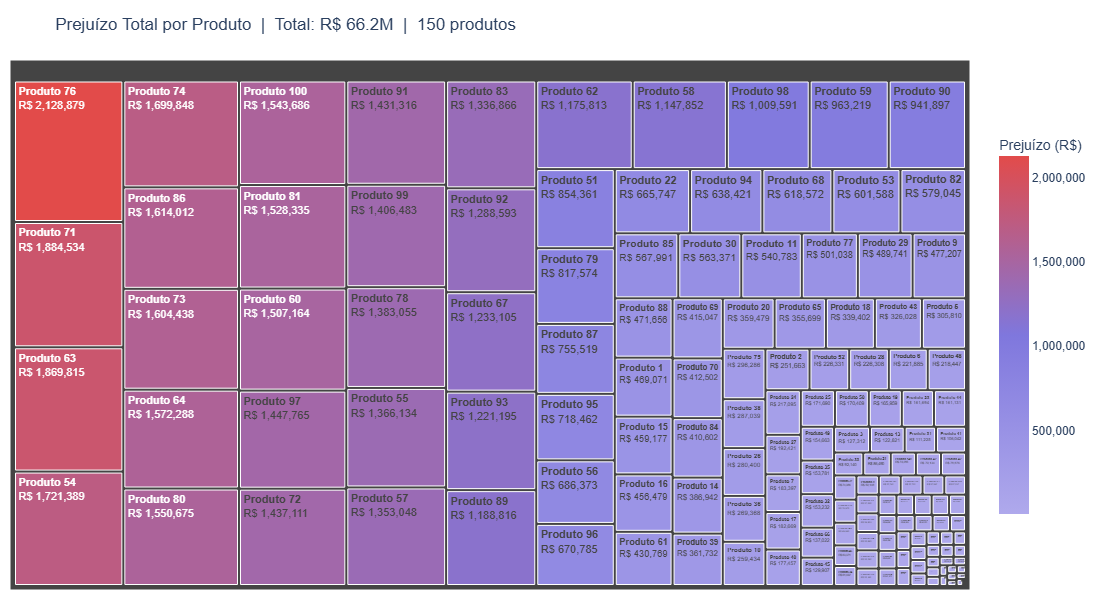

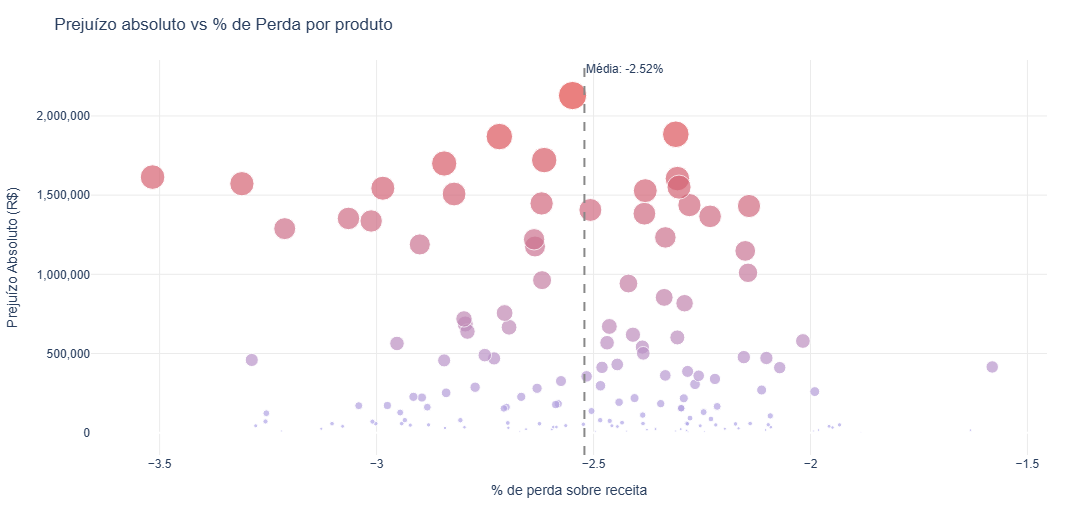

In [92]:

# Carregue o CSV
df_prejuizo = pd.read_csv(FILE_RELACAO_PREJUIZO)
 
# Preparação dos dados
df_prejuizo["prejuizo_abs"] = df_prejuizo["prejuizo_total"].abs()
df_prejuizo["produto_label"] = "Produto " + df_prejuizo["id_product"].astype(str)
 
# Texto exibido dentro de cada bloco do treemap
df_prejuizo["hover_text"] = (
    "Prejuízo: R$ " + (df_prejuizo["prejuizo_abs"] / 1e6).round(3).astype(str) + "M"
    + "<br>% Perda: " + df_prejuizo["percentual_perda"].round(2).astype(str) + "%"
    + "<br>Receita: R$ " + (df_prejuizo["receita_total"] / 1e6).round(2).astype(str) + "M"
)
 
total_prejuizo = df_prejuizo["prejuizo_abs"].sum()
maior_produto  = df_prejuizo.loc[df_prejuizo["prejuizo_abs"].idxmax(), "produto_label"]
maior_valor    = df_prejuizo["prejuizo_abs"].max()
 

# Treemap principal (todos os 150 produtos)
fig_tree = px.treemap(
    df_prejuizo,
    path=["produto_label"],
    values="prejuizo_abs",
    color="prejuizo_abs",
    color_continuous_scale=["#AFA9EC", "#7F77DD", "#E24B4A"],   # roxo → vermelho
    custom_data=["percentual_perda", "receita_total", "prejuizo_abs"],
    title=(
        f"Prejuízo Total por Produto  |  "
        f"Total: R$ {total_prejuizo/1e6:.1f}M  |  "
        f"150 produtos"
    ),
)
 
fig_tree.update_traces(
    hovertemplate=(
        "<b>%{label}</b><br>"
        "Prejuízo: R$ %{customdata[2]:,.0f}<br>"
        "% Perda:  %{customdata[0]:.2f}%<br>"
        "Receita:  R$ %{customdata[1]:,.0f}"
        "<extra></extra>"
    ),
    texttemplate="<b>%{label}</b><br>R$ %{value:,.0f}",
    textfont_size=11,
)
 
fig_tree.update_layout(
    height=600,
    coloraxis_colorbar=dict(
        title="Prejuízo (R$)",
        tickformat=",.0f",
        len=0.75,
    ),
    margin=dict(t=60, l=10, r=10, b=10),
    font=dict(family="Arial, sans-serif"),
)
 
fig_tree.show()
 
# Scatter plot — Prejuízo vs % de perda
fig_scatter = px.scatter(
    df_prejuizo,
    x="percentual_perda",
    y="prejuizo_abs",
    size="prejuizo_abs",
    color="prejuizo_abs",
    color_continuous_scale=["#AFA9EC", "#E24B4A"],
    hover_name="produto_label",
    custom_data=["receita_total", "percentual_perda", "prejuizo_abs"],
    title="Prejuízo absoluto vs % de Perda por produto",
    labels={
        "percentual_perda": "% de perda sobre receita",
        "prejuizo_abs": "Prejuízo Absoluto (R$)",
    },
)
 
fig_scatter.update_traces(
    hovertemplate=(
        "<b>%{hovertext}</b><br>"
        "Prejuízo: R$ %{customdata[2]:,.0f}<br>"
        "% Perda:  %{customdata[1]:.2f}%<br>"
        "Receita:  R$ %{customdata[0]:,.0f}"
        "<extra></extra>"
    )
)
 
# Linha de média do percentual de perda
media_pct = df_prejuizo["percentual_perda"].mean()
fig_scatter.add_vline(
    x=media_pct,
    line_dash="dash",
    line_color="#888",
    annotation_text=f"Média: {media_pct:.2f}%",
    annotation_position="top right",
)
 
fig_scatter.update_layout(
    height=500,
    plot_bgcolor="white",
    paper_bgcolor="white",
    xaxis=dict(showgrid=True, gridcolor="#EBEBEB"),
    yaxis=dict(showgrid=True, gridcolor="#EBEBEB", tickformat=",.0f"),
    coloraxis_showscale=False,
    margin=dict(t=60, l=80, r=40, b=60),
    font=dict(family="Arial, sans-serif", size=12),
)
 
fig_scatter.show()

Salvando nossos gráficos como arquivo html localmente

In [69]:
TREE_MAP = OUTPUT_DIR / 'treemap_prejuizo.html'
SCATTER = OUTPUT_DIR / 'scatter_prejuizo.html'

fig_tree.write_html(TREE_MAP)
fig_scatter.write_html(SCATTER)
print(" Os arquivos foram salvos com sucesso na pasta 'output'!")

 Os arquivos foram salvos com sucesso na pasta 'output'!


---
<h1>Questão 3</h1>
Converter arquivo JSON para CSV de forma estruturada.

In [70]:
# Carregar o arquivo JSON
with open(FILE_CUSTOS_JSON, 'r', encoding='utf-8') as f:
    dados_json = json.load(f)

# Achatar (Normalizar) o JSON
df_importacao = pd.json_normalize(
    dados_json,
    record_path=['historic_data'],
    meta=['product_id', 'product_name', 'category']
)

# Reorganizar a ordem das colunas para bater com o seu requisito
df_importacao = df_importacao[['product_id', 'product_name', 'category', 'start_date', 'usd_price']]

# Garantir os tipos de dados (Tipagem forte)
df_importacao['product_id'] = df_importacao['product_id'].astype(int)
df_importacao['usd_price'] = df_importacao['usd_price'].astype(float)

# Converte a data no formato YYYY-MM-DD
df_importacao['start_date'] = pd.to_datetime(df_importacao['start_date'], format='%d/%m/%Y').dt.strftime('%Y-%m-%d')

# Exportar para o novo arquivo CSV com segurança de diretório
FILE_CUSTOS_NORM.parent.mkdir(parents=True, exist_ok=True)
df_importacao.to_csv(FILE_CUSTOS_NORM, index=False)

# Calculando numero de entradas de importação
total_entradas = df_importacao.shape[0]
print(f"Sucesso! O arquivo foi salvo em: {FILE_CUSTOS_NORM.resolve()}")
print(f"RESPOSTA: O CSV recebeu ao todo {total_entradas} entradas de importação após a normalização.")

Sucesso! O arquivo foi salvo em: C:\Users\Lucas\Documents\Projetos\desafio_indicium\datasets\processed\custos_importacao_normalizado.csv
RESPOSTA: O CSV recebeu ao todo 1260 entradas de importação após a normalização.


O CSV recebeu um total de 1260 entradas de importação, correspondente à expansão dos históricos de preços dos 150 produtos.

---
<h1>Questão 4 - Dados Públicos</h1>

<h3>Buscando dados da cotação do dolar no banco central 

In [71]:
# Definir as datas
data_inicial = '01-01-2015'
data_final = '12-31-2025'

# Montar a URL da API
url_bcb = (
    f"https://olinda.bcb.gov.br/olinda/servico/PTAX/versao/v1/odata/"
    f"CotacaoDolarPeriodo(dataInicial=@dataInicial,dataFinalCotacao=@dataFinalCotacao)?"
    f"@dataInicial='{data_inicial}'&@dataFinalCotacao='{data_final}'&$format=json"
)

# Fazer a requisição
print("Buscando cotações de venda do Banco Central...")
response = requests.get(url_bcb)

if response.status_code == 200:
    dados_json = response.json()['value']
    df_cambio = pd.DataFrame(dados_json)
    
    # Extrair apenas a data e filtrar a cotação de venda
    df_cambio['data'] = pd.to_datetime(df_cambio['dataHoraCotacao']).dt.date
    df_cambio = df_cambio[['data', 'cotacaoVenda']]
    df_cambio = df_cambio.rename(columns={'cotacaoVenda': 'media_diaria_venda'})
    df_cambio = df_cambio.drop_duplicates(subset='data', keep='last')    
    
    # Garante que a pasta exista
    FILE_COTACAO.parent.mkdir(parents=True, exist_ok=True)
    
    # Salva o arquivo diretamente usando a nossa constante
    df_cambio.to_csv(FILE_COTACAO, index=False)
    
    print(f"Pronto! Arquivo salvo com sucesso em:\n{FILE_COTACAO.resolve()}")
    display(df_cambio.head()) 

else:
    print(f"Erro ao acessar a API. Código: {response.status_code}")

Buscando cotações de venda do Banco Central...
Pronto! Arquivo salvo com sucesso em:
C:\Users\Lucas\Documents\Projetos\desafio_indicium\datasets\processed\cotacao_dolar.csv


,data,media_diaria_venda
0,2015-01-02,2.6929
1,2015-01-05,2.7107
2,2015-01-06,2.7023
3,2015-01-07,2.6807
4,2015-01-08,2.6919


In [72]:
with open(FILE_JSON, 'r', encoding='utf-8') as f:
    dados_json = json.load(f)

# Achatar (Normalizar) o JSON
df_importacao = pd.json_normalize(
    dados_json,
    record_path=['historic_data'],
    meta=['product_id', 'product_name', 'category']
)

# Reorganizar as colunas e forçar a tipagem
df_importacao = df_importacao[['product_id', 'product_name', 'category', 'start_date', 'usd_price']]

df_importacao['product_id'] = df_importacao['product_id'].astype(int)
df_importacao['usd_price'] = df_importacao['usd_price'].astype(float)
df_importacao['start_date'] = pd.to_datetime(df_importacao['start_date'], format='%d/%m/%Y') 


# Exportação e Validação

FILE_CSV_SAIDA.parent.mkdir(parents=True, exist_ok=True)

# Exporta para CSV
df_importacao.to_csv(FILE_CSV_SAIDA, index=False)

# Retorno para o Analista
total_entradas = df_importacao.shape[0]
print("ETL Concluído com Sucesso!")
# O método .resolve() mostra o caminho absoluto certinho do computador na hora do print
print(f"Arquivo salvo em: {FILE_CSV_SAIDA.resolve()}") 
print(f"RESPOSTA: O CSV recebeu ao todo {total_entradas} entradas de importação após a normalização.")

ETL Concluído com Sucesso!
Arquivo salvo em: C:\Users\Lucas\Documents\Projetos\desafio_indicium\datasets\processed\custos_importacao_normalizado.csv
RESPOSTA: O CSV recebeu ao todo 1260 entradas de importação após a normalização.


<h3>Gerando gráficos para visualização de prejuizo

In [73]:
# Lendo o arquivo
df = pd.read_csv(FILE_RELACAO_PREJUIZO)

# Visualizando as primeiras linhas
df.head()

,id_product,receita_total,prejuizo_total,percentual_perda
0,1,17187280.35,-469070.67,-2.7292
1,2,8862231.15,-251662.73,-2.8397
2,3,4322136.25,-127312.00,-2.9456
3,4,1915160.00,-43172.40,-2.2542
4,5,13494880.35,-305809.84,-2.2661


---
<h1>Questão 7 - Previsão de Demanda

In [74]:
# Carregar e Filtrar os Dados
vendas7 = pd.read_csv(FILE_VENDAS_NORMALIZADA)
produtos7 = pd.read_csv(FILE_PRODUTOS_PROCESSED)

df_completo = pd.merge(vendas7, produtos7, left_on='id_product', right_on='code', how='inner')
df_motor = df_completo[df_completo['name'] == 'Motor de Popa Yamaha Evo Dash 155HP'].copy()
df_motor['sale_date'] = pd.to_datetime(df_motor['sale_date'], format='mixed', dayfirst=True)

In [75]:
# Criar a Série Contínua (Preenchendo os dias sem venda com 0)
vendas_diarias = df_motor.groupby('sale_date')['qtd'].sum().reset_index()

data_min = vendas_diarias['sale_date'].min()
data_max = pd.to_datetime('2024-01-31')
calendario = pd.DataFrame({'sale_date': pd.date_range(start=data_min, end=data_max)})

serie_completa = pd.merge(calendario, vendas_diarias, on='sale_date', how='left').fillna(0)
serie_completa = serie_completa.sort_values('sale_date')

In [79]:
# Criando modelo de média móvel (BASELINE)
# shift(1): Pega o dado do dia anterior (Garante que não há data leakage)
# rolling(7): Pega a janela dos últimos 7 dias
# mean(): Calcula a média dessa janela
serie_completa['previsao_ma7'] = serie_completa['qtd'].shift(1).rolling(window=7).mean()

# Arredondando porque não vendemos "meio" motor
# O fillna(0) trata os primeiros 7 dias de 2023 que ficarão vazios por falta de histórico anterior
serie_completa['previsao_ma7'] = np.round(serie_completa['previsao_ma7'].fillna(0))

In [80]:
# Split treino/teste
# Isolamos apenas Janeiro de 2024 para o teste
teste = serie_completa[(serie_completa['sale_date'] >= '2024-01-01') & 
                       (serie_completa['sale_date'] <= '2024-01-31')].copy()

treino = serie_completa[serie_completa['sale_date'] <= '2023-12-31'].copy()

In [81]:
# Mean Absolute Error (Erro Médio Absoluto)
mae_ma7 = mean_absolute_error(teste['qtd'], teste['previsao_ma7'])

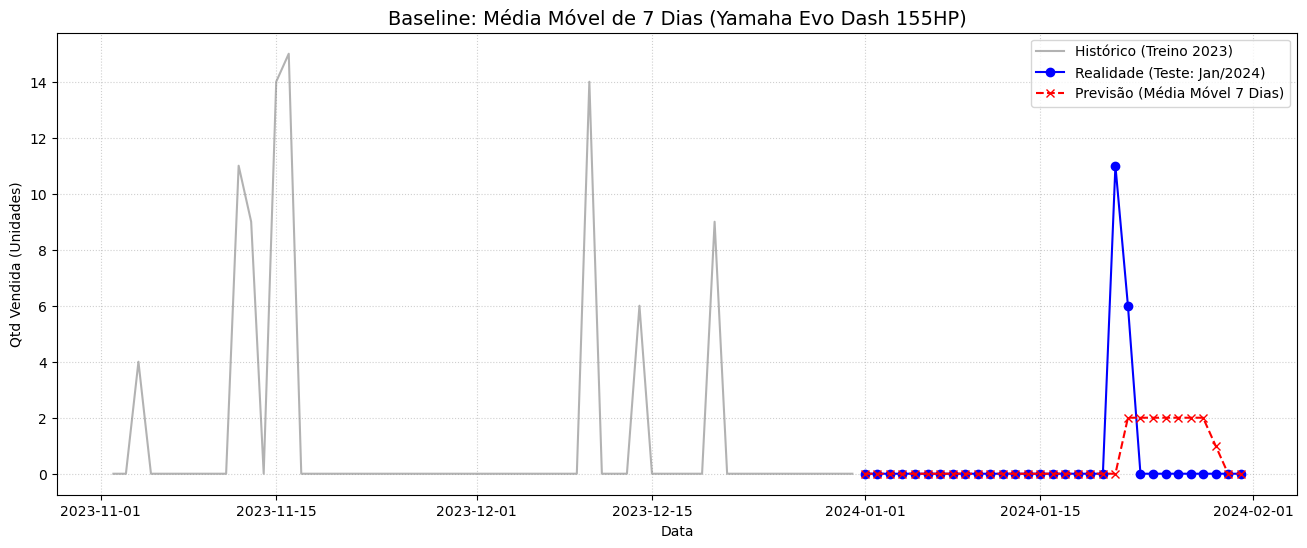

--------------------------------------------------
AVALIAÇÃO DO MODELO DE MÉDIA MÓVEL - JAN/2024
--------------------------------------------------
Total REAL vendido em Jan/24       : 17 unidades
Total PREVISTO pelo modelo (MA7)   : 15 unidades
Métrica MAE (Mean Absolute Error)  : 0.90 unidades de erro por dia


In [84]:
# visualização dos resultados
plt.figure(figsize=(16, 6))

plt.plot(treino['sale_date'][-60:], treino['qtd'][-60:], label='Histórico (Treino 2023)', color='gray', alpha=0.6)
plt.plot(teste['sale_date'], teste['qtd'], label='Realidade (Teste: Jan/2024)', color='blue', marker='o')
plt.plot(teste['sale_date'], teste['previsao_ma7'], label='Previsão (Média Móvel 7 Dias)', color='red', linestyle='--', marker='x')

plt.title('Baseline: Média Móvel de 7 Dias (Yamaha Evo Dash 155HP)', fontsize=14)
plt.xlabel('Data')
plt.ylabel('Qtd Vendida (Unidades)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# Resumo Final e Cálculo do MAE
print("-" * 50)
print(f"AVALIAÇÃO DO MODELO DE MÉDIA MÓVEL - JAN/2024")
print("-" * 50)
print(f"Total REAL vendido em Jan/24       : {teste['qtd'].sum():.0f} unidades")
print(f"Total PREVISTO pelo modelo (MA7)   : {teste['previsao_ma7'].sum():.0f} unidades")
print(f"Métrica MAE (Mean Absolute Error)  : {mae_ma7:.2f} unidades de erro por dia")

---
<h1>Questão 8 - Sistema de Recomendação</h1>

In [85]:
# Carregar as tabelas
vendas_8 = pd.read_csv(FILE_VENDAS)
produtos_8 = pd.read_csv(FILE_PRODUTOS_PROCESSED)

# Exibir uma mensagem de confirmação
print(f"Vendas carregadas: {vendas_8.shape[0]} linhas.")
print(f"Produtos carregados: {produtos_8.shape[0]} itens.")

Vendas carregadas: 9895 linhas.
Produtos carregados: 150 itens.


In [90]:
# MATRIZ DE INTERAÇÃO (PRESENÇA/AUSÊNCIA)

# 1. Filtramos usando o novo DataFrame vendas_8 e removemos duplicatas
interacoes = vendas_8[['id_client', 'id_product']].drop_duplicates().copy()

# 2. Criamos uma coluna artificial chamada 'comprou' com o número 1
interacoes['comprou'] = 1

# 3. Criamos a Matriz Pivot
matriz_interacao = interacoes.pivot(
    index='id_client', 
    columns='id_product', 
    values='comprou'
).fillna(0)

print("Matriz de Interação criada com sucesso!")
print(f"Dimensões: {matriz_interacao.shape[0]} Clientes x {matriz_interacao.shape[1]} Produtos")
display(matriz_interacao.head())

Matriz de Interação criada com sucesso!
Dimensões: 49 Clientes x 150 Produtos


id_product,1,2,3,4,5,6,7,8,9,10,...,141,142,143,144,145,146,147,148,149,150
id_client,,,,,,,,,,,,,,,,,,,,,
1,1.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0
2,0.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0
3,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,...,0.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0
4,1.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,...,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0
5,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0


In [87]:
# MATRIZ DE SIMILARIDADE DE COSSENO

# Transpor a matriz (Linhas viram produtos, colunas viram clientes)
matriz_produtos = matriz_interacao.T

# Calcular a similaridade matemática
similaridade_array = cosine_similarity(matriz_produtos)

# Transformar o resultado de volta em um DataFrame
df_similaridade = pd.DataFrame(
    similaridade_array,
    index=matriz_produtos.index,
    columns=matriz_produtos.index
)

print("Similaridade Produto x Produto calculada!")
display(df_similaridade.head())

Similaridade Produto x Produto calculada!


id_product,1,2,3,4,5,6,7,8,9,10,...,141,142,143,144,145,146,147,148,149,150
id_product,,,,,,,,,,,,,,,,,,,,,
1,1.000000,0.775058,0.737865,0.810191,0.748331,0.769484,0.775058,0.727825,0.711512,0.698771,...,0.795133,0.753819,0.775058,0.769484,0.721605,0.775058,0.872082,0.721605,0.727825,0.775058
2,0.775058,1.000000,0.704295,0.757865,0.714286,0.712931,0.771429,0.750290,0.788811,0.687256,...,0.795192,0.778078,0.771429,0.767772,0.685714,0.742857,0.712931,0.628571,0.750290,0.742857
3,0.737865,0.704295,1.000000,0.800641,0.704295,0.865181,0.732467,0.712396,0.777778,0.707107,...,0.675923,0.739795,0.732467,0.757033,0.704295,0.788811,0.729996,0.732467,0.739795,0.704295
4,0.810191,0.757865,0.800641,1.000000,0.757865,0.753310,0.757865,0.789747,0.773953,0.735980,...,0.831239,0.789747,0.730798,0.779287,0.730798,0.730798,0.805263,0.757865,0.763422,0.757865
5,0.748331,0.714286,0.704295,0.757865,1.000000,0.795192,0.742857,0.694713,0.760639,0.627495,...,0.795192,0.722501,0.714286,0.685511,0.685714,0.714286,0.767772,0.657143,0.722501,0.714286


In [89]:
# Ranking de recomendação top 5

NOME_ALVO = 'GPS Garmin Vortex Maré Drift'

# Descobrir o ID buscando no novo DataFrame produtos_8
id_alvo = produtos_8.loc[produtos_8['name'] == NOME_ALVO, 'code'].values[0]

# Pegar as similaridades apenas desse GPS e ordenar
similares_ao_alvo = df_similaridade[id_alvo].sort_values(ascending=False)

# Remover o próprio GPS da lista
similares_ao_alvo = similares_ao_alvo.drop(id_alvo)

# Pegar o Top 5
top_5_ids = similares_ao_alvo.head(5).reset_index()
top_5_ids.columns = ['id_product', 'score_similaridade']

# Fazer o JOIN com produtos_8 para trazer os nomes e categorias
ranking_final = pd.merge(
    top_5_ids, 
    produtos_8[['code', 'name', 'actual_category']], 
    left_on='id_product', 
    right_on='code', 
    how='left'
)

# Exibir o resultado final
print("-" * 60)
print(f" PRODUTO REFERÊNCIA: {NOME_ALVO}")
print("-" * 60)
print("Os 5 produtos mais recomendados para venda cruzada (Cross-Sell) são:\n")

# Formatando o score
ranking_final['score_similaridade'] = (ranking_final['score_similaridade'] * 100).round(2).astype(str) + '%'

display(ranking_final[['name', 'actual_category', 'score_similaridade']])

------------------------------------------------------------
 PRODUTO REFERÊNCIA: GPS Garmin Vortex Maré Drift
------------------------------------------------------------
Os 5 produtos mais recomendados para venda cruzada (Cross-Sell) são:



,name,actual_category,score_similaridade
0,Motor de Popa Volvo Magnum 276HP,propulsão,86.96%
1,GPS Furuno Swift Leviathan Poseidon,eletrônicos,86.8%
2,Radar Furuno Swift,eletrônicos,85.39%
3,Cabo de Nylon Delta Force Magnum Leviathan,ancoragem,85.0%
4,Transponder AIS Maré Magnum,eletrônicos,85.0%
